In [ ]:
import numpy as np
import torch
from matplotlib import pyplot as plt

In [ ]:
from helper_functions.helper_functions import TSR_extrapolation

data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/param_fbh_gaussian_size5mm_depth80pct_thickness6mm.npz',allow_pickle=True)
polate=TSR_extrapolation()
Yh2,a,Y2=polate(data,ord=2)

In [2]:
from networks.Unets import BnetMean, BnetSmallKernel,BnetSmallKernelSmarter,BnetTiny
from data.data_operators import BScanDepthDatasetExp
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
sim_dataset = BScanDepthDatasetExp(
        bscan_dir=r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/all_data_same_length_no_base_add_noise_test/Test_sample_sim_4_mm_different_length/B_scans",
        normalization_path=r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/normalization_params.npz"
    )

In [4]:
exp_dataset = BScanDepthDatasetExp(
        bscan_dir=r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Two_real_samples/thick_sample_10s/thick_sample_10s_bscans",
        normalization_path=r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/normalization_params.npz"
    )

In [5]:
sim_loader=DataLoader(sim_dataset,batch_size=1,shuffle=False)
exp_loader=DataLoader(exp_dataset,batch_size=1,shuffle=False)

In [6]:
tinynet=BnetTiny()
state_dict=torch.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/Unet_bnettiny_l2_both_classes.pth")
tinynet.load_state_dict(state_dict)
tinynet.to(device='cuda')
tinynet.eval()


meanet=BnetMean()
state_dict=torch.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/Unet_mean_l2_both_classes.pth")
meanet.load_state_dict(state_dict)
meanet.to(device='cuda')
meanet.eval()


kernet=BnetSmallKernel()
state_dict=torch.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/Unet_small_kernel_l2_both_classes.pth")
kernet.load_state_dict(state_dict)
kernet.to(device='cuda')
kernet.eval()


smartnet=BnetSmallKernelSmarter()
state_dict=torch.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/Unet_small_kernel_smarter_l2_both_classes.pth")
smartnet.load_state_dict(state_dict)
smartnet.to(device='cuda')
smartnet.eval()

BnetSmallKernelSmarter(
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

In [7]:
sim_data=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Models_lc_and_test_data/all_data_same_length_no_base_add_noise_test/Test_sample_sim_4_mm_different_length/param_fbh_gaussian_size20mm_depth40pct_thickness4mm.npz",allow_pickle=True)
sim_data['data'].shape

(244, 512, 512)

In [8]:
net_result=[]
models=[tinynet,meanet,kernet,smartnet]
with torch.no_grad():
    for i in range(4):
        all_preds = []  
        for batch in sim_loader:
            x = batch  # your batch of inputs
            x=x.to(device='cuda')
            pred = models[i](x)
            all_preds.append(pred)
        all_preds = torch.cat(all_preds, dim=0)    
        net_result.append(all_preds)

Text(0.5, 1.0, 'B-net smart network')

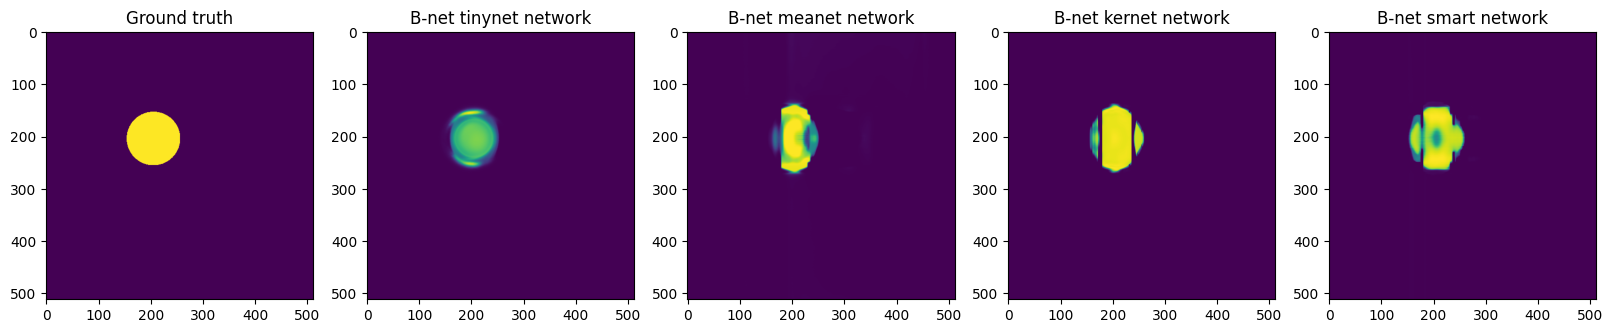

In [9]:
plt.figure(figsize=(20,15))
plt.subplot(1,5,1)
plt.imshow(sim_data['mask'])
plt.title('Ground truth')

plt.subplot(1,5,2)
plt.imshow(net_result[0].detach().cpu())
plt.title('B-net tinynet network')

plt.subplot(1,5,3)
plt.imshow(net_result[1].detach().cpu())
plt.title('B-net meanet network')

plt.subplot(1,5,4)
plt.imshow(net_result[2].detach().cpu())
plt.title('B-net kernet network')

plt.subplot(1,5,5)
plt.imshow(net_result[3].detach().cpu())
plt.title('B-net smart network')

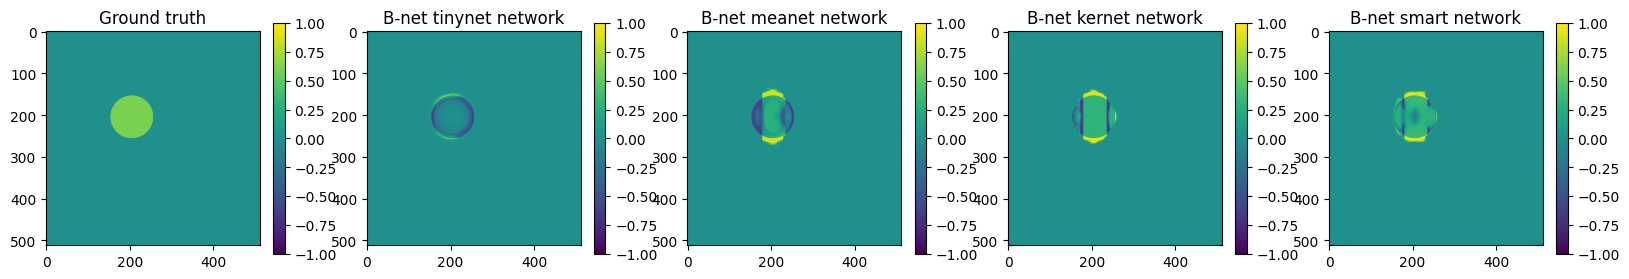

In [10]:
plt.figure(figsize=(20,15))
plt.subplot(1,5,1)
plt.imshow(sim_data['mask']*0.6,vmin=-1,vmax=1.0)
plt.title('Ground truth')
plt.colorbar(shrink=0.2)

plt.subplot(1,5,2)
plt.imshow(net_result[0].detach().cpu().numpy()-sim_data['mask']*0.6,vmin=-1,vmax=1.0)
plt.title('B-net tinynet network')
plt.colorbar(shrink=0.2)

plt.subplot(1,5,3)
plt.imshow(net_result[1].detach().cpu().numpy()-sim_data['mask']*0.6,vmin=-1,vmax=1.0)
plt.title('B-net meanet network')
plt.colorbar(shrink=0.2)

plt.subplot(1,5,4)
plt.imshow(net_result[2].detach().cpu().numpy()-sim_data['mask']*0.6,vmin=-1,vmax=1.0)
plt.title('B-net kernet network')
plt.colorbar(shrink=0.2)

plt.subplot(1,5,5)
plt.imshow(net_result[3].detach().cpu().numpy()-sim_data['mask']*0.6,vmin=-1,vmax=1.0)
plt.title('B-net smart network')
plt.colorbar(shrink=0.2)

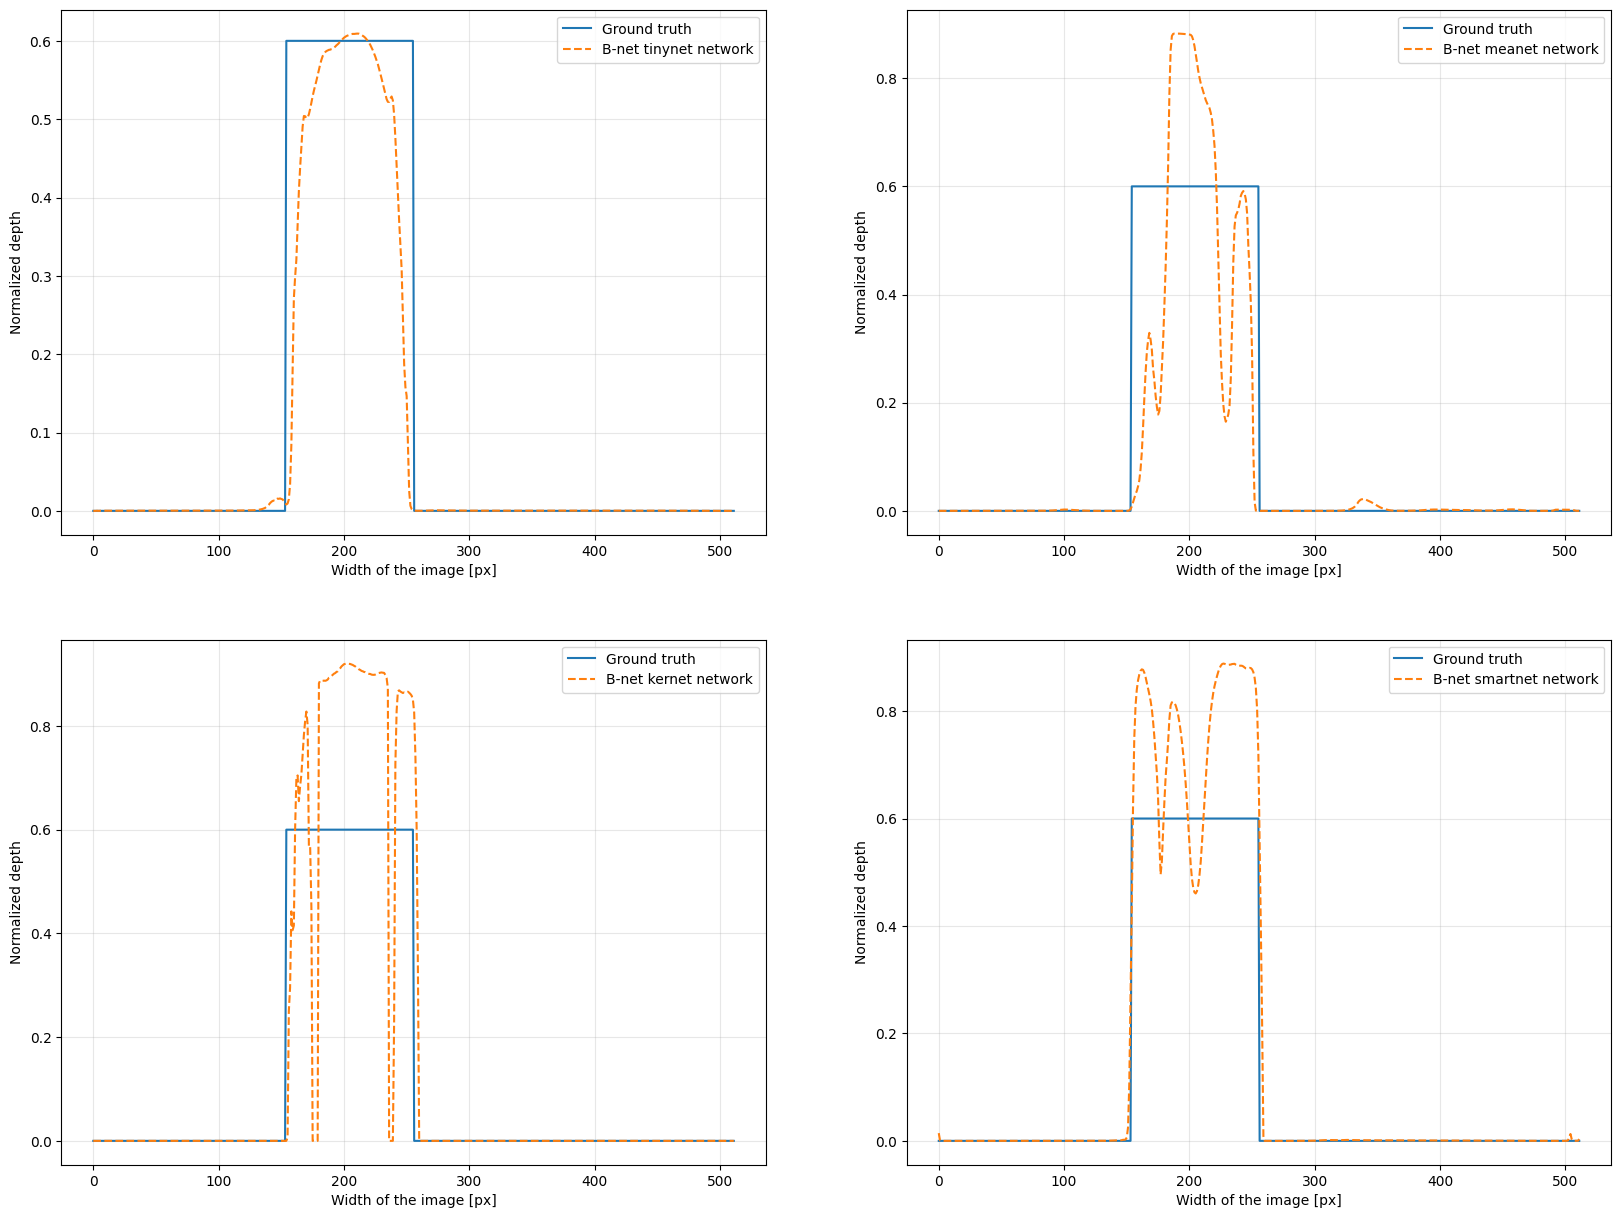

In [11]:
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
plt.plot(sim_data['mask'][200,:]*0.6,label='Ground truth')
plt.plot(net_result[0][200,:].detach().cpu(),label='B-net tinynet network',linestyle='dashed')
plt.xlabel('Width of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,2)
plt.plot(sim_data['mask'][200,:]*0.6,label='Ground truth')
plt.plot(net_result[1][200,:].detach().cpu(),label='B-net meanet network',linestyle='dashed')
plt.xlabel('Width of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,3)
plt.plot(sim_data['mask'][200,:]*0.6,label='Ground truth')
plt.plot(net_result[2][200,:].detach().cpu(),label='B-net kernet network',linestyle='dashed')
plt.xlabel('Width of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,4)
plt.plot(sim_data['mask'][200,:]*0.6,label='Ground truth')
plt.plot(net_result[3][200,:].detach().cpu(),label='B-net smartnet network',linestyle='dashed')
plt.xlabel('Width of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

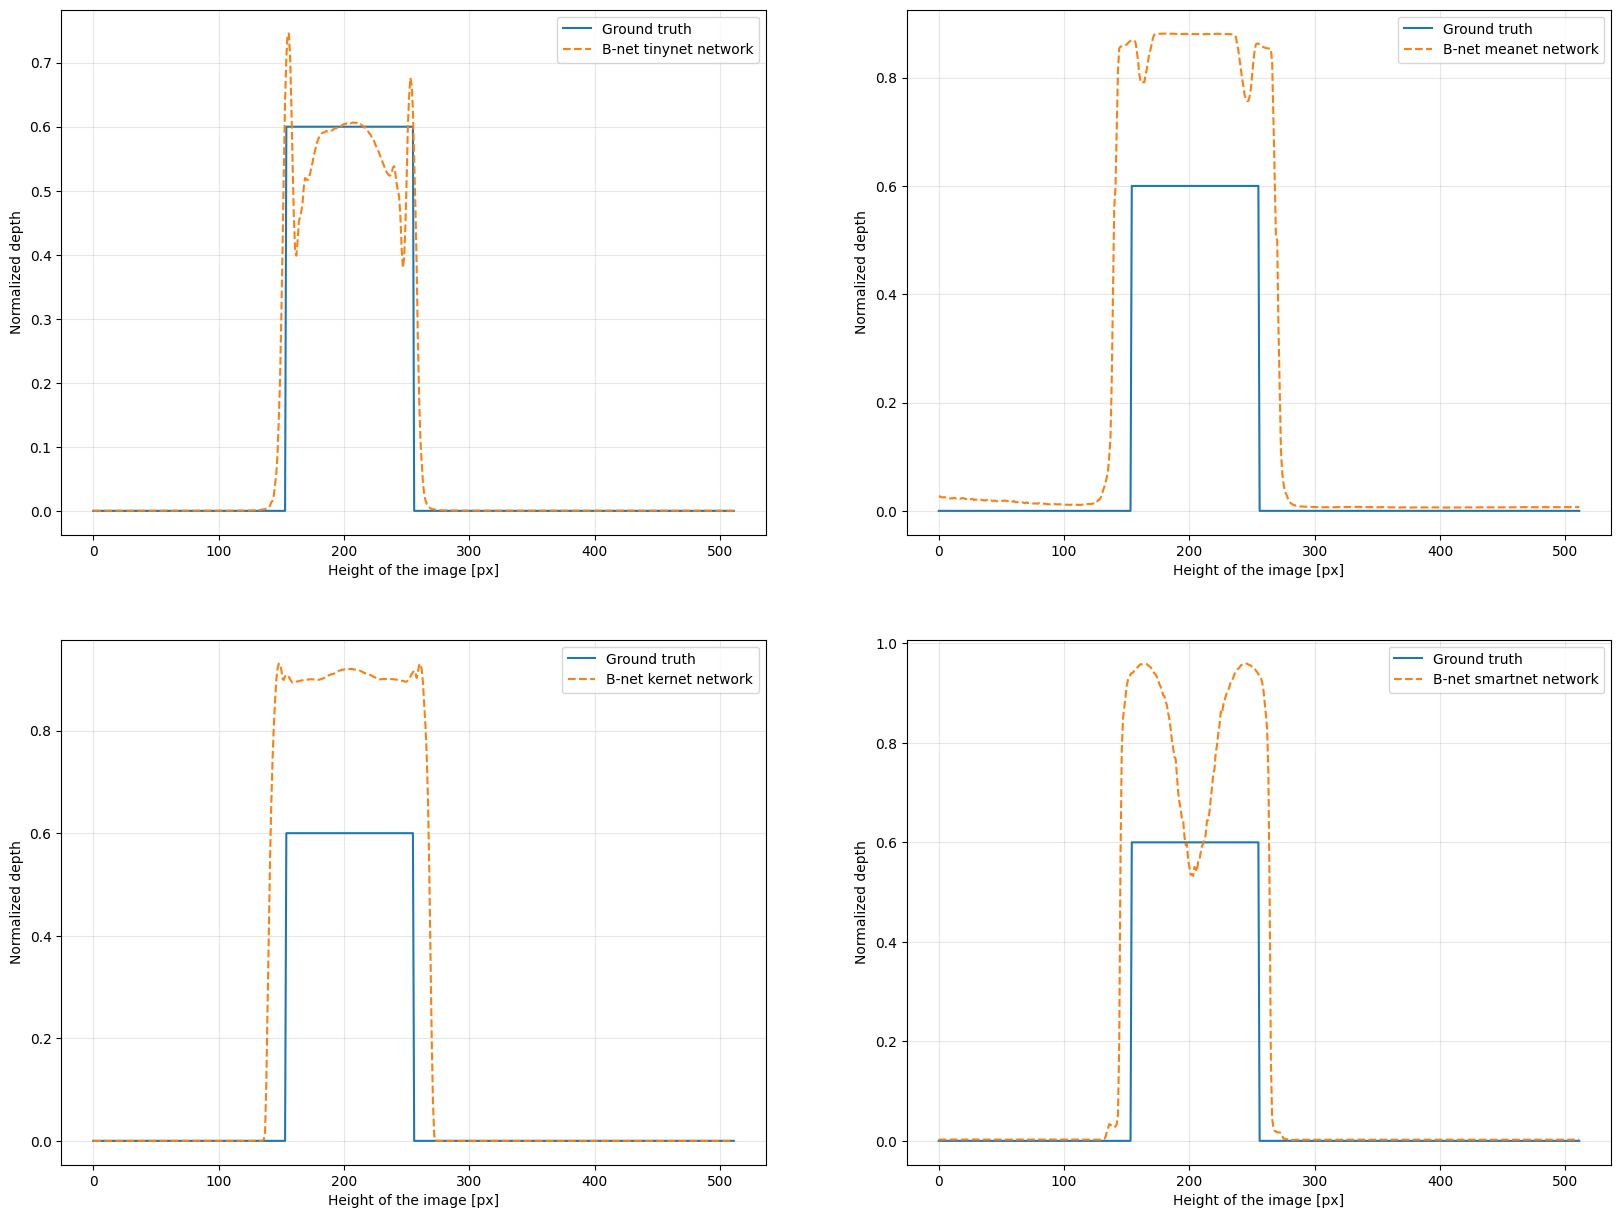

In [12]:
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
plt.plot(sim_data['mask'][:,200]*0.6,label='Ground truth')
plt.plot(net_result[0][:,200].detach().cpu(),label='B-net tinynet network',linestyle='dashed')
plt.xlabel('Height of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,2)
plt.plot(sim_data['mask'][:,200]*0.6,label='Ground truth')
plt.plot(net_result[1][:,200].detach().cpu(),label='B-net meanet network',linestyle='dashed')
plt.xlabel('Height of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,3)
plt.plot(sim_data['mask'][:,200]*0.6,label='Ground truth')
plt.plot(net_result[2][:,200].detach().cpu(),label='B-net kernet network',linestyle='dashed')
plt.xlabel('Height of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2,2,4)
plt.plot(sim_data['mask'][:,200]*0.6,label='Ground truth')
plt.plot(net_result[3][:,200].detach().cpu(),label='B-net smartnet network',linestyle='dashed')
plt.xlabel('Height of the image [px]')
plt.ylabel('Normalized depth')
plt.legend()
plt.grid(alpha=0.3)